In [18]:
from matplotlib import animation
from matplotlib import pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import os
from datetime import datetime   

In [35]:
os.path.exists('../tests/boid_runs/first.npz')

True

In [ ]:
name = '../tests'
result = find_dir(name)
print(result)

#nts currentlyy trying to remember how the fuck this function works lol
#nts2 realising that i need to restructure this function:
'''
    needs to:
        given a string:
            figure out if the user meant it as a name or a path
            if path, make this this path, and assign name and path to self based on path with same suffix (run)

            intiliase the name iter as -1, (less than 0 no iter)
            when saving in future, if iter is >-1, add it to the prefix, counting untill a file not using that name
            in the same current directory exists

'''

('12-02-2026-1336-59', '../tests')


In [ ]:
def make_file_name(path:str):
    """
        if the path is directory, name the runs the smallest number iter inside said directory
    """

    if os.path.isdir(path):
        iter = ""

        directory_name = os.path.dirname(path)

        file_name_candidate = f"{directory_name}{iter}.npz"
        while os.path.exists(file_name_candidate):
            #the following is only for the first iteration:
            if isinstance(iter,str): iter = 0
            else: iter+=1
                
            if iter-10 > len(os.listdir(path)):
                raise Exception("Couldn't find a valid name when saving the file. Iterations exceeded number of files in the directory. Could")
        
        self.out_dir = path
        return file_name_candidate
    else:
        raise FileNotFoundError(f"Directory {path} doesn't exist or cant be found.")
                

In [ ]:
def find_dir(path:str,name:str = False,its=0):
    '''
    Docstring for find_or_make_dir
    :return: tuple(save path, save name) savename will default to datetime if no option provided
    '''
    if its > 1: raise Exception(f'Could not find path {path}')

    time_now = datetime.now().strftime('%d-%m-%Y-%H%M-%S')

    if os.path.exists(path):
        if os.path.isdir(path):
            if name: return name, path
            else:    return time_now, path
        else:
            print(f'{path} already exists as a file')
            raise FileExistsError
    else:
        dirname = os.path.dirname(path)
        name = os.path.basename(path)
        return find_dir(dirname,name,1)

# Testing
Testing some things, can be ignored

In [2]:
def new_flock(count, lower_limits, upper_limits):
    width = upper_limits - lower_limits
    return lower_limits[:, np.newaxis] + np.random.rand(2, count) * width[:, np.newaxis]

In [4]:
boid_count = 10
limits = np.array([2000, 2000]) #edges of the sim

positions = new_flock(boid_count, 
                      np.array([100, 900]), 
                      np.array([200, 1100]))

velocities = new_flock(boid_count, 
                       np.array([0, -20]), 
                       np.array([10, 20]))


In [ ]:


def animate(frame):
    update_boids(positions, velocities)
    scatter.set_offsets(positions.transpose())

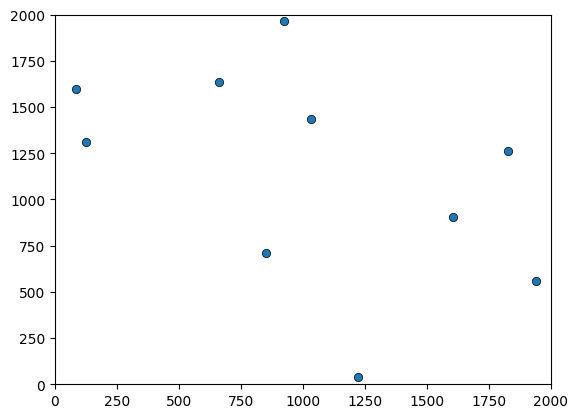

In [10]:
figure = plt.figure()
axes = plt.axes(xlim=(0, limits[0]), ylim=(0, limits[1]))
scatter = axes.scatter(positions[0, :], positions[1, :], marker="o", edgecolor="k", lw=0.5)

In [11]:
anim = animation.FuncAnimation(figure, animate, frames=50, interval=50)
anim.save("boids_1.gif")

/Users/cosmo/Library/Python/3.9/lib/python/site-packages/matplotlib/animation.py:892: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


# Global Consts

In [ ]:
"""
THIS ONE IS HOW THE PAPER INITS ITS VARIABLES:


"""

# force constants
K_SPEED = 10.0
K_REPULSION = 1
K_ALIGNMENT = 0.1
K_HOMING = 2.0
K_FRICTION = 20.0
K_PREDATOR  = 100

# sigmoidal function
ALPHA = 200.0
BETA = 0.1

# neighbour radii
RAD_REPULSION = 1
RAD_ALIGNMENT = 1
RAD_PREDATOR = 1

# time step / simulation
DELTA_T = 0.02

# Lorenz conditions
L_SIGMA = 10.0
L_RHO = 28.0
L_BETA = 8/3  
    # Initial Positions
X_LORENZ = 0.0
Y_LORENZ = 1.0
Z_LORENZ = 1.05

In [ ]:
# force constants
K_SPEED = 10.0
K_REPULSION = 20
K_ALIGNMENT = 0.1
K_HOMING = 2.0
K_FRICTION = 16.0
K_PREDATOR = 100

# sigmoidal function
ALPHA = 200.0
BETA = 0.001

# neighbour radii
RAD_REPULSION = 50
RAD_ALIGNMENT = 20
RAD_PREDATOR = 1


# time step / simulation
DELTA_T = 0.02


# Lorenz conditions
L_SIGMA = 10.0
L_RHO = 28.0
L_BETA = 8/3  
    # Initial Positions
X_LORENZ = 0.0
Y_LORENZ = 1.0
Z_LORENZ = 1.05

# Boid Functions
$ where\ X\ is\ position\ and\ V\ is\ velocity$

### Check Neighbours

In [ ]:
def update_neighbours(neis):
    """
    key:
    0 - no neighbours
    1 - alignment and repulsion
    2 - alignemnt
    3 - repulsion
    """
    for k,v in neis.items():
        for subs in v:
            new_neighbour_value = 0
            if (    (distance(k,subs) <= RAD_REPULSION) 
                    and 
                    (distance(k,subs) <= RAD_ALIGNMENT)):
                
                new_neighbour_value = 1

            elif (  (distance(k,subs) > RAD_REPULSION) 
                    and 
                    (distance(k,subs) <= RAD_ALIGNMENT)):
                
                new_neighbour_value = 2

            elif (  (distance(k,subs) <= RAD_REPULSION) 
                    and 
                    (distance(k,subs) > RAD_ALIGNMENT)):
                
                new_neighbour_value = 3

            neighbours[k][subs] = new_neighbour_value



def get_neighbours(neis):
    """
    takes the sub array of the neighbour matrix which encodes whether a given boid (based) on index is within range

    Returns: [0] of either return gives the positions, [1] gives the velocties
    \n
    a - 3D array containing the x,v of each boid within the alignment radius 
    \n
    r - tuple containing the x,v of each boid within the repulsion radius
    """

    a = []
    r = []

    for i,b in enumerate(neis):
        if b == 1:
            a.append(i)
            r.append(i)
        elif b == 2:
            a.append(i)
        elif b == 3:
            r.append(i)
    
    a_x = [positions[i] for i in a]
    a_v = [velocities[i] for i in a]
    a = np.array([a_x,a_v])

    r_x = [positions[i] for i in r]
    r_v = [velocities[i] for i in r]
    r = np.array([r_x,r_v])

    return a, r



In [15]:
def distance(n1:int,n2:int):
    boid1 = positions[n1]
    boid2 = positions[n2]
    
    dist = np.linalg.norm(boid1 - boid2)

    return dist

**Repulsion $r$**

### $\sum_{j=1}^{N_r}\frac{X_i - X_j}{||{X_i - X_j}||^2}$




In [11]:
def repulsion_force(boid,neis_x,debug=False):
    """ 
        boid is an np.array(2) [x,y] of a given boid
        neighoburs is an np.array(2,n) where n is the number of neighbours
    """
    force = np.array([0.0,0.0])
    for n in neis_x:
        if np.array_equal(n,boid): continue  # boids consider themselves neighbours
                                # this is useful for finding the avg position in homing, but should be skipped here

        numerator = boid - n

        denom = np.linalg.norm(boid-n) ** 2
        force += (numerator/denom)

        if(debug): 
            print(f'Force total: {force}')
            print(f'\t{numerator} / {denom} = {numerator/denom}')
            print(f'\tXi = {boid}, Xj = {n}')
    
    return force





**Alignment $a$**
### $\sum_{j=1}^{N_a}V_j - V_i$

In [12]:
def alignment_force(boid_v,neis_v):
    """ 
        boid is an np.array(2) [x,y] of a given boid's velocity
        neighoburs is an np.array(2,n) where n is the number of neighbours, and gives the velocities of all the neighbours
    """
    force = np.array([0.0,0.0])
    
    for n in neis_v:
        force+= n - boid_v
    return force

def alignment_neighbours():
    return

**Homing $h$**
### $X_h - X_i$

$X_h\ is\ the\ home\ location\ of\ each\ agent\ and\ in\ this\ example\ the\ home\ location\ is\ the\ origin$ 

In [13]:
def homing_force(boid,home=np.array([0.0,0.0])):
    return home-boid

 **Friction**
$F_{f_{i}} = -V_i\frac{(||V_i||-s)}{s}$

In [ ]:
def friction_force(boid_v):
    denom = (np.linalg.norm(boid_v) - K_SPEED) * (boid_v*-1)
    force = denom/K_SPEED
    return force

**Predator Force**

### $F_{pi} = H(r_p - ||X_i - X_p||)\frac{X_i - X_p}{||X_i-X_p||^2}$
the heaviside function here is essentially just an if statement based on whether the boid is in range.<br>
If its in range, it multiplies by one (activates), otherwise it multiplies by 0

In [ ]:
def predator_force(boid_x,pred_x):
    """
        takes boid position and predator position
    """
    if pred_x==None: return np.array([0.0,0.0]
    # this if else is the heaviside function
    if(distance(boid_x,pred_x)<=RAD_PREDATOR):
        numer = boid_x-pred_x
        denom = np.linalg.norm(boid_x-pred_x)**2
        return (numer/denom)
    else:
        return np.array([0.0,0.0])


## Total Force
without predator<br>
$F_{i}(t) = K_{a}F_{ai} + K_{r}F_{ri} + K_{f}F_{fi} + K_{h}F_{hi}$
<br>
<br>
with predator<br>
$F_{i}(t) = K_{a}F_{ai} + K_{r}F_{ri} + K_{f}F_{fi} + K_{h}F_{hi} + K_{p}F_{pi}$
<br>

$F_i(t)\mapsto \alpha\ tanh(\beta F_i(t))$


In [ ]:
def total_force(boid_x,boid_v,a_neighbours,r_neighbours,pred=None,debug=False):

#            |-coefficent---|-force---------|-force-params---------|
    force = ((K_ALIGNMENT*  alignment_force (boid_v,a_neighbours[1])) +
            (K_REPULSION *  repulsion_force (boid_x,r_neighbours[0])) +
            (K_FRICTION  *  friction_force  (boid_v)) +
            (K_HOMING    *  homing_force    (boid_x)) +
            (K_PREDATOR   *  predator_force  (boid_x,pred) ))       

    # sigmoidal function
    force_sigmoid = ALPHA * np.tanh(BETA * force)

    # debug showing all the forces
    if(debug):
       print(   
                f'Force: {force} Force Sigmoid: {force_sigmoid}',
                f'\n\tFa: { K_ALIGNMENT*alignment_force(boid_v,a_neighbours[1]) }',
                f'\n\tFr: { K_REPULSION*repulsion_force(boid_x,r_neighbours[0]) }',
                f'\n\tFf: { K_FRICTION*friction_force(boid_v) }',
                f'\n\tFh: { K_HOMING*homing_force(boid_x) }',
                f'\n\tFp: { K_PREDATOR *predator_force(boid_x,pred) }')
       
    return force_sigmoid





def force_matrix(xs,vs,ns,debug=False):
    forces = np.empty((len(xs),2))
    for i,x in enumerate(xs):
        v = vs[i]
        n_a, n_r = get_neighbours(ns[i])

        forces[i] = total_force(x,v,n_a,n_r,debug)
    return forces

# Simulation

## Debug

In [52]:
def view_boid(pos,vel,nei,label):
    print(pos[label])
    print(vel[label])
    print(nei[label])

In [77]:
view_boid(positions,velocities,neighbours,3)

[ 143.75872113 1078.35460016]
[0. 0.]
[3, 3, 0, 1, 0, 0, 0, 0, 0, 0]


## Init

In [22]:
def generate_flock(flock_size,lim,random_v=False):

    x = np.random.uniform(lim[0], lim[1], size=(flock_size, 2))

    if random_v: v=np.random.rand(flock_size,2)
    else: v = np.zeros((flock_size,2),dtype=float)

    # dictionary mapping the number tag of each boid to a bit array of its near neighbours
    n = {i:[0] * flock_size for i in range(flock_size)}

    # returns positions, velocities, neighbour data
    return x, v, n

In [ ]:
# testing

boid_count = 100
spawn_bounds = [np.array([500, 500]), np.array([200, 400])] #edges of the sim,

positions, velocities, neighbours = generate_flock(boid_count,spawn_bounds[0],spawn_bounds[1])

## Running

$V_i(t+\Delta t)=V_i(t) + F_i(t)\Delta t$
<br>
<br>
$X_i(t+\Delta t)=X_i(t)+V_i(t)\Delta t$

In [ ]:
def evolution_update():
    """
    1. Calculate neighbours
    2. Create force matrix
    3. update velocity matrix
    4. update position matrix
    """
    update_neighbours(neighbours)
    fm = force_matrix(positions,velocities,neighbours,False)
    for i,v in enumerate(velocities):
        positions[i]+= v * DELTA_T
        velocities[i]+=fm[i] * DELTA_T

    
def animate(frame):
    evolution_update()
    quiver.set_offsets(positions)

    normalised_vels = velocities*0.001

    quiver.set_UVC(normalised_vels[:, 0], normalised_vels[:, 1])
    scatter.set_offsets(positions)
    

In [ ]:
os.path

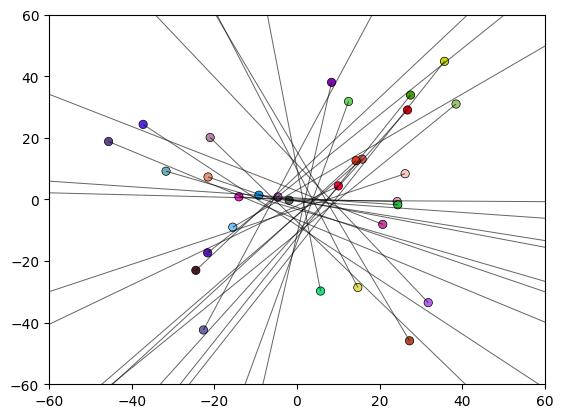

In [ ]:
np.random.seed(20)

sim_size = np.array([-60, 60])

run_time = 1 # in seconds

boid_count = 30

positions, velocities, neighbours = generate_flock(boid_count,sim_size)

figure = plt.figure()
colors = np.random.rand(boid_count, 3)
axes = plt.axes(xlim=(sim_size[0], sim_size[1]), ylim=(sim_size[0], sim_size[1]))
scatter = axes.scatter(
    positions[:, 0], 
    positions[:, 1], 
    marker="o", 
    edgecolor="k", 
    lw=0.5,
    c=colors)



quiver = axes.quiver(
    positions[:, 0], positions[:, 1],
    velocities[:, 0], velocities[:, 1],
    width=0.002,
    alpha=0.6,
)


anim = animation.FuncAnimation(figure, animate, frames=int(run_time/DELTA_T), interval=DELTA_T*1000)
anim.save("gifs/boids_1.gif")

# Lorenz


## Online Example
https://scipython.com/blog/the-lorenz-attractor/

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create an image of the Lorenz attractor.
# The maths behind this code is described in the scipython blog article
# at https://scipython.com/blog/the-lorenz-attractor/
# Christian Hill, January 2016.
# Updated, January 2021 to use scipy.integrate.solve_ivp.

WIDTH, HEIGHT, DPI = 1000, 750, 100

# Lorenz paramters and initial conditions.
sigma, beta, rho = 10, 2.667, 28
u0, v0, w0 = 0, 1, 1.05

# Maximum time point and total number of time points.
tmax, n = 100, 10000

def lorenz(t, X, sigma, beta, rho):
    """The Lorenz equations."""
    u, v, w = X
    up = -sigma*(u - v)
    vp = rho*u - v - u*w
    wp = -beta*w + u*v
    return up, vp, wp

# Integrate the Lorenz equations.
soln = solve_ivp(lorenz, (0, tmax), (u0, v0, w0), args=(sigma, beta, rho),dense_output=True)
# Interpolate solution onto the time grid, t.
t = np.linspace(0, tmax, n)
x, y, z = soln.sol(t)

# Plot the Lorenz attractor using a Matplotlib 3D projection.
fig = plt.figure(facecolor='k', figsize=(WIDTH/DPI, HEIGHT/DPI))
ax = fig.add_subplot(111, projection='3d') #MODIFIED THIS LINE
ax.set_facecolor('k')
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

# Make the line multi-coloured by plotting it in segments of length s which
# change in colour across the whole time series.
s = 10
cmap = plt.cm.winter
for i in range(0,n-s,s):
    ax.plot(x[i:i+s+1], y[i:i+s+1], z[i:i+s+1], color=cmap(i/n), alpha=0.4)

# Remove all the axis clutter, leaving just the curve.
ax.set_axis_off()

plt.savefig('images/lorenz.png', dpi=DPI)
plt.show()

: 

## My Implementation

In [8]:
# Lorenz sim variables
tmax, l_points = 100, 10000

### $\dot{x_L}=\sigma(y_L - x_L),$
### $\dot{y_L}=x_L(\rho - z_L)-y_L,$
### $\dot{z_L}=x_Ly_L-\beta z_L$

In [9]:
def lorenz_equations(start_states):
    x,y,z = start_states
    x_dot = L_RHO * (y-x)
    y_dot = x * (L_RHO - z) - y
    z_dot = (x * y) - (L_BETA * z)
    return x_dot,y_dot,z_dot

lorenz_equations(X_LORENZ,Y_LORENZ,Z_LORENZ)

soln = solve_ivp(lorenz_equations,(0,tmax),(X_LORENZ,Y_LORENZ,Z_LORENZ),dense_output=True)
t = np.linspace(0, tmax, n)

NameError: name 'X_LORENZ' is not defined